# Open Source Libraries in APK Files — Scaled Dataset Trend Analysis

This notebook analyzes multiple APK-library detection datasets generated from increasing APK collection sizes: **10, 20, 40, 60, and 80 APKs**.

For each dataset, it:

- Loads `dataset_10.csv`, `dataset_20.csv`, `dataset_30.csv`, ... , and `dataset_700.csv`
- Creates two binary origin columns:
  - `origin_fingerprint`
  - `origin_license_exposure`
- Calculates the requested KPIs for every dataset size
- Saves per-size outputs into `OUTPUT_DIR`
- Creates trend charts showing how KPIs change as the number of APK files increases

The main goal is to understand how increasing the APK collection size impacts open-source library occurrence counts, unique library counts, citation coverage, origin coverage, and fingerprint type distribution.

## 1. Setup

Adjust `DATA_PATH` and `OUTPUT_DIR` if your folder structure is different.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# More readable notebook tables
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 140)

DATA_PATH = Path('../analysis_datasets')
OUTPUT_DIR = Path('../analysis_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(filename: str, dpi: int = 300) -> Path:
    """Save the active matplotlib figure as a PNG in OUTPUT_DIR."""
    output_path = OUTPUT_DIR / filename
    if output_path.suffix.lower() != '.png':
        output_path = output_path.with_suffix('.png')
    plt.savefig(output_path, dpi=dpi, bbox_inches='tight')
    return output_path

DATASET_NAME = 'dataset_'
DATASET_SUFFIX = [10, 20, 30, 40, 60, 80, 100, 150, 200, 300, 500, 700]

required_columns = [
    'pkg_name',
    'repo_url',
    'cited',
    'origin',
    'fingerprint_types'
]

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Data folder not found: {DATA_PATH.resolve()}')

print(f'Data folder: {DATA_PATH.resolve()}')
print(f'Output folder: {OUTPUT_DIR.resolve()}')

Data folder: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/analysis_datasets
Output folder: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/analysis_outputs


## 2. Helper functions

These functions keep the analysis consistent across all dataset sizes.

In [2]:
def load_dataset(dataset_size: int) -> pd.DataFrame:
    """Load a dataset by APK collection size, for example dataset_10.csv."""
    file_path = DATA_PATH / f'{DATASET_NAME}{dataset_size}.csv'
    if not file_path.exists():
        raise FileNotFoundError(f'Missing expected dataset file: {file_path.resolve()}')
    
    df = pd.read_csv(file_path)
    df['dataset_size'] = dataset_size
    df['source_file'] = file_path.name
    return df


def validate_columns(df: pd.DataFrame, dataset_size: int) -> None:
    """Validate that required analysis columns exist."""
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise KeyError(f'Dataset {dataset_size} is missing required columns: {missing}')


def transform_origin_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Create binary indicators from origin and normalize cited to 0/1 integer values."""
    df = df.copy()
    
    df['origin_clean'] = df['origin'].fillna('').astype(str).str.lower()
    df['origin_fingerprint'] = df['origin_clean'].str.contains('fingerprints', regex=False).astype(int)
    df['origin_license_exposure'] = df['origin_clean'].str.contains('license_exposure', regex=False).astype(int)
    
    # Keep cited as a numeric 0/1 indicator.
    # Invalid or missing values are treated as 0.
    df['cited'] = pd.to_numeric(df['cited'], errors='coerce').fillna(0).astype(int)
    df['cited'] = df['cited'].clip(lower=0, upper=1)
    
    return df


def explode_fingerprint_types(df: pd.DataFrame) -> pd.DataFrame:
    """Split comma-separated fingerprint_types into one row per type."""
    cols = ['dataset_size', 'pkg_name', 'repo_url', 'fingerprint_types']
    available_cols = [col for col in cols if col in df.columns]
    fp = df[available_cols].copy()
    fp['fingerprint_types'] = fp['fingerprint_types'].fillna('').astype(str)
    fp['fingerprint_type'] = fp['fingerprint_types'].str.split(',')
    fp = fp.explode('fingerprint_type')
    fp['fingerprint_type'] = fp['fingerprint_type'].astype(str).str.strip()
    fp = fp[fp['fingerprint_type'] != '']
    fp = fp[fp['fingerprint_type'].str.lower() != 'nan']
    return fp


def calculate_kpis(df: pd.DataFrame, dataset_size: int) -> dict:
    """Calculate the requested KPIs for one dataset."""
    total_rows = len(df)
    total_cited_1 = int((df['cited'] == 1).sum())
    total_cited_0 = int((df['cited'] == 0).sum())
    cited_1_fingerprint = int(((df['cited'] == 1) & (df['origin_fingerprint'] == 1)).sum())
    cited_1_license = int(((df['cited'] == 1) & (df['origin_license_exposure'] == 1)).sum())
    
    rows_per_pkg = df.groupby('pkg_name', dropna=False).size()
    
    return {
        'dataset_size': dataset_size,
        'total_rows_library_occurrences': total_rows,
        'unique_pkg_count': df['pkg_name'].nunique(dropna=True),
        'unique_repo_url_count': df['repo_url'].nunique(dropna=True),
        'cited_1_count': total_cited_1,
        'cited_0_count': total_cited_0,
        'cited_1_ratio_per_total_rows': total_cited_1 / total_rows if total_rows else np.nan,
        'cited_0_ratio_per_total_rows': total_cited_0 / total_rows if total_rows else np.nan,
        'cited_1_found_by_fingerprint_count': cited_1_fingerprint,
        'cited_1_found_by_fingerprint_ratio_per_cited_1': cited_1_fingerprint / total_cited_1 if total_cited_1 else np.nan,
        'cited_1_found_by_license_exposure_count': cited_1_license,
        'cited_1_found_by_license_exposure_ratio_per_cited_1': cited_1_license / total_cited_1 if total_cited_1 else np.nan,
        'rows_per_pkg_mean': rows_per_pkg.mean() if len(rows_per_pkg) else np.nan,
        'rows_per_pkg_median': rows_per_pkg.median() if len(rows_per_pkg) else np.nan,
        'rows_per_pkg_min': rows_per_pkg.min() if len(rows_per_pkg) else np.nan,
        'rows_per_pkg_max': rows_per_pkg.max() if len(rows_per_pkg) else np.nan,
        'rows_per_pkg_std': rows_per_pkg.std() if len(rows_per_pkg) > 1 else 0,
    }

## 3. Load, transform, and save every dataset

Each transformed dataset is saved separately in `OUTPUT_DIR` using the dataset size suffix.

In [3]:
all_datasets = []
kpi_records = []
rows_per_pkg_records = []
fingerprint_type_records = []

for size in DATASET_SUFFIX:
    df_size = load_dataset(size)
    validate_columns(df_size, size)
    df_size = transform_origin_columns(df_size)
    
    # Save transformed dataset for this size
    transformed_path = OUTPUT_DIR / f'dataset_{size}_transformed.csv'
    df_size.to_csv(transformed_path, index=False)
    
    # KPI summary for this size
    kpi_records.append(calculate_kpis(df_size, size))
    
    # Rows per APK/package for distribution analysis
    rows_per_pkg = (
        df_size.groupby('pkg_name', dropna=False)
        .size()
        .reset_index(name='library_occurrence_rows')
    )
    rows_per_pkg['dataset_size'] = size
    rows_per_pkg_records.append(rows_per_pkg)
    rows_per_pkg.to_csv(OUTPUT_DIR / f'rows_per_pkg_{size}.csv', index=False)
    
    # Fingerprint type distribution for this size
    fp_exploded = explode_fingerprint_types(df_size)
    fp_summary = (
        fp_exploded.groupby('fingerprint_type')
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    fp_total = fp_summary['count'].sum()
    fp_summary['ratio'] = fp_summary['count'] / fp_total if fp_total else np.nan
    fp_summary['dataset_size'] = size
    fingerprint_type_records.append(fp_summary)
    fp_summary.to_csv(OUTPUT_DIR / f'fingerprint_type_summary_{size}.csv', index=False)
    
    all_datasets.append(df_size)
    print(f'Loaded dataset_{size}.csv: {len(df_size):,} rows, {df_size["pkg_name"].nunique():,} APK packages')

combined_df = pd.concat(all_datasets, ignore_index=True)
kpi_summary = pd.DataFrame(kpi_records).sort_values('dataset_size').reset_index(drop=True)
rows_per_pkg_all = pd.concat(rows_per_pkg_records, ignore_index=True)
fingerprint_type_summary_all = pd.concat(fingerprint_type_records, ignore_index=True)

# Save combined outputs
combined_df.to_csv(OUTPUT_DIR / 'all_datasets_transformed_combined.csv', index=False)
kpi_summary.to_csv(OUTPUT_DIR / 'kpi_summary_by_dataset_size.csv', index=False)
rows_per_pkg_all.to_csv(OUTPUT_DIR / 'rows_per_pkg_all_dataset_sizes.csv', index=False)
fingerprint_type_summary_all.to_csv(OUTPUT_DIR / 'fingerprint_type_summary_all_dataset_sizes.csv', index=False)

print('Saved combined and per-size outputs to:', OUTPUT_DIR.resolve())

Loaded dataset_10.csv: 123 rows, 8 APK packages
Loaded dataset_20.csv: 1,820 rows, 18 APK packages
Loaded dataset_30.csv: 2,614 rows, 30 APK packages
Loaded dataset_40.csv: 3,426 rows, 40 APK packages
Loaded dataset_60.csv: 5,340 rows, 60 APK packages
Loaded dataset_80.csv: 7,329 rows, 80 APK packages
Loaded dataset_100.csv: 11,122 rows, 100 APK packages
Loaded dataset_150.csv: 17,215 rows, 150 APK packages
Loaded dataset_200.csv: 24,672 rows, 200 APK packages
Loaded dataset_300.csv: 38,880 rows, 300 APK packages
Loaded dataset_500.csv: 72,328 rows, 500 APK packages
Loaded dataset_700.csv: 108,234 rows, 699 APK packages
Saved combined and per-size outputs to: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/analysis_outputs


## 4. KPI summary table

This table shows the main KPIs for each APK collection size.

In [4]:
display_columns = [
    'dataset_size',
    'total_rows_library_occurrences',
    'unique_pkg_count',
    'unique_repo_url_count',
    'cited_1_count',
    'cited_0_count',
    'cited_1_ratio_per_total_rows',
    'cited_0_ratio_per_total_rows',
    'cited_1_found_by_fingerprint_count',
    'cited_1_found_by_fingerprint_ratio_per_cited_1',
    'cited_1_found_by_license_exposure_count',
    'cited_1_found_by_license_exposure_ratio_per_cited_1',
    'rows_per_pkg_mean',
    'rows_per_pkg_median',
    'rows_per_pkg_min',
    'rows_per_pkg_max'
]

kpi_summary[display_columns]

,dataset_size,total_rows_library_occurrences,unique_pkg_count,unique_repo_url_count,cited_1_count,cited_0_count,cited_1_ratio_per_total_rows,cited_0_ratio_per_total_rows,cited_1_found_by_fingerprint_count,cited_1_found_by_fingerprint_ratio_per_cited_1,cited_1_found_by_license_exposure_count,cited_1_found_by_license_exposure_ratio_per_cited_1,rows_per_pkg_mean,rows_per_pkg_median,rows_per_pkg_min,rows_per_pkg_max
0,10,123,8,23,89,34,0.723577,0.276423,44,0.494382,62,0.696629,15.375000,12.0,8,42
1,20,1820,18,113,1544,276,0.848352,0.151648,1292,0.836788,339,0.219560,101.111111,99.0,12,262
2,30,2614,30,128,2033,581,0.777735,0.222265,1767,0.869159,383,0.188392,87.133333,82.5,2,262
3,40,3426,40,135,2542,884,0.741973,0.258027,2252,0.885917,422,0.166011,85.650000,91.5,2,262
4,60,5340,60,153,3810,1530,0.713483,0.286517,3410,0.895013,553,0.145144,89.000000,96.0,2,262
5,80,7329,80,165,4939,2390,0.673898,0.326102,4501,0.911318,597,0.120875,91.612500,98.5,2,262
6,100,11122,100,184,7639,3483,0.686837,0.313163,7151,0.936117,756,0.098966,111.220000,114.0,2,262
7,150,17215,150,311,10925,6290,0.634621,0.365379,10181,0.931899,1255,0.114874,114.766667,116.0,1,283
8,200,24672,200,325,14878,9794,0.603032,0.396968,14113,0.948582,1300,0.087377,123.360000,116.0,1,333
9,300,38880,300,392,22190,16690,0.570730,0.429270,21044,0.948355,1741,0.078459,129.600000,124.0,1,373


## 5. Trend: total open-source library occurrences

This shows how the total number of detected open-source library occurrences changes as the APK collection grows.

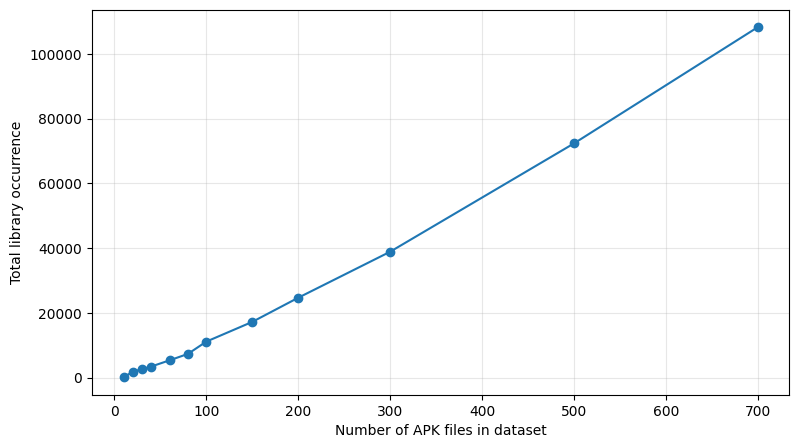

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(
    kpi_summary['dataset_size'],
    kpi_summary['total_rows_library_occurrences'],
    marker='o'
)
# plt.title('Total Open-Source Library Occurrences by APK Collection Size')
plt.xlabel('Number of APK files in dataset')
plt.ylabel('Total library occurrence')
plt.grid(True, alpha=0.3)
save_current_figure('total_library_occurrences_by_apk_collection_size.png')
plt.show()

## 6. Trend: unique open-source libraries

`repo_url` is used as the open-source library identifier. This chart shows whether the number of unique libraries grows as more APKs are included.

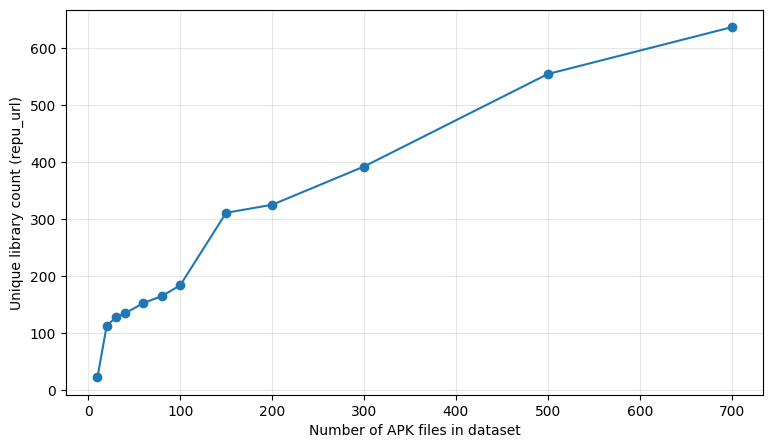

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(
    kpi_summary['dataset_size'],
    kpi_summary['unique_repo_url_count'],
    marker='o'
)
# plt.title('Unique Open-Source Libraries by APK Collection Size')
plt.xlabel('Number of APK files in dataset')
plt.ylabel('Unique library count (repu_url)')
plt.grid(True, alpha=0.3)
save_current_figure('unique_open_source_libraries_by_apk_collection_size.png')
plt.show()

## 7. Trend: cited vs. not cited counts

This compares the absolute counts of rows where `cited = 1` and `cited = 0`.

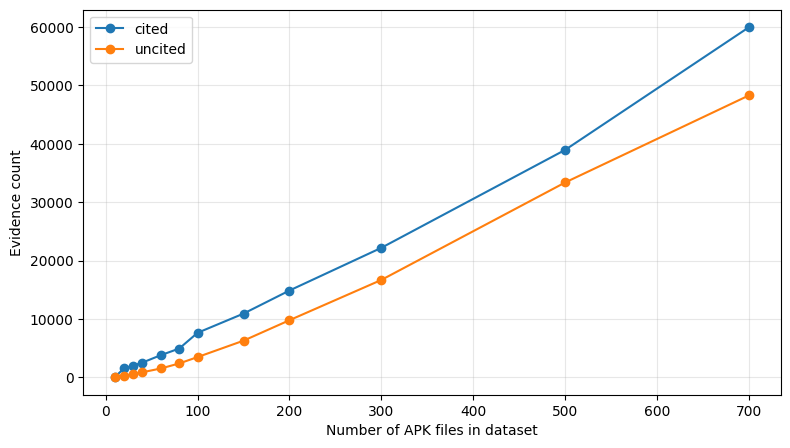

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(kpi_summary['dataset_size'], kpi_summary['cited_1_count'], marker='o', label='cited')
plt.plot(kpi_summary['dataset_size'], kpi_summary['cited_0_count'], marker='o', label='uncited')
# plt.title('Cited vs. Uncited Counts by APK Collection Size')
plt.xlabel('Number of APK files in dataset')
plt.ylabel('Evidence count')
plt.legend()
plt.grid(True, alpha=0.3)
save_current_figure('cited_vs_not_cited_counts_by_apk_collection_size.png')
plt.show()

## 8. Trend: cited ratio

This chart shows the proportion of all rows where `cited = 1` or `cited = 0`.

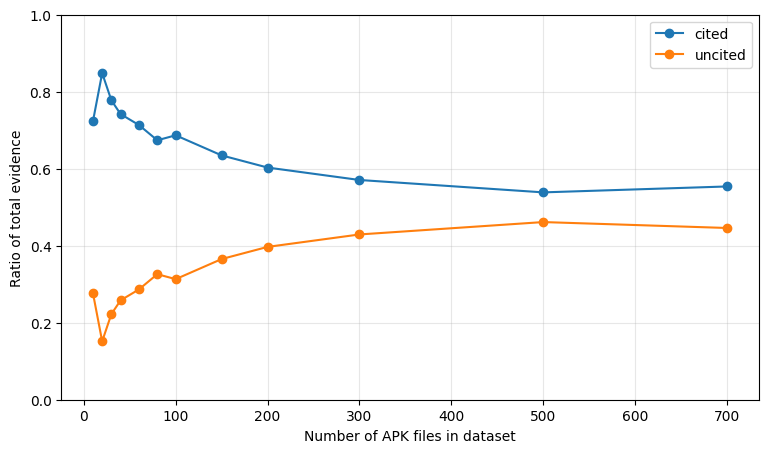

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(kpi_summary['dataset_size'], kpi_summary['cited_1_ratio_per_total_rows'], marker='o', label='cited')
plt.plot(kpi_summary['dataset_size'], kpi_summary['cited_0_ratio_per_total_rows'], marker='o', label='uncited')
# plt.title('Cited Ratio by APK Collection Size')
plt.xlabel('Number of APK files in dataset')
plt.ylabel('Ratio of total evidence')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
save_current_figure('cited_ratio_by_apk_collection_size.png')
plt.show()

## 9. Trend: cited rows by detection origin

For rows where `cited = 1`, this shows what share was found by fingerprints and license exposure.

Because one row can contain both origins, these ratios are not required to sum to 100%.

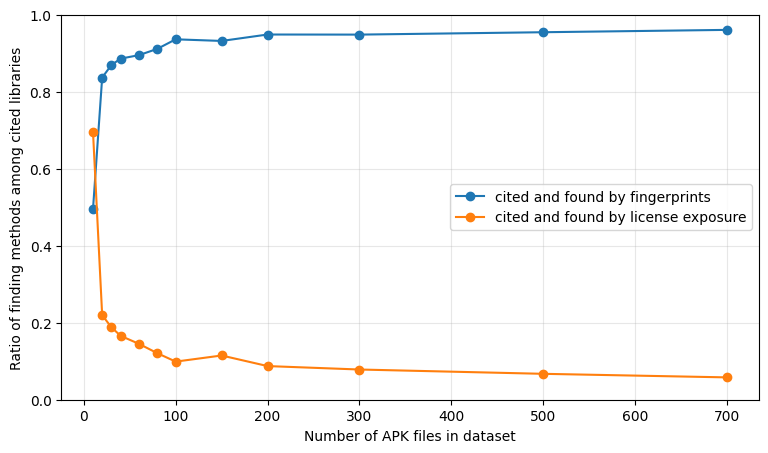

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(
    kpi_summary['dataset_size'],
    kpi_summary['cited_1_found_by_fingerprint_ratio_per_cited_1'],
    marker='o',
    label='cited and found by fingerprints'
)
plt.plot(
    kpi_summary['dataset_size'],
    kpi_summary['cited_1_found_by_license_exposure_ratio_per_cited_1'],
    marker='o',
    label='cited and found by license exposure'
)
# plt.title('Origin Coverage Among Cited Rows by APK Collection Size')
plt.xlabel('Number of APK files in dataset')
plt.ylabel('Ratio of finding methods among cited libraries')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
save_current_figure('origin_coverage_among_cited_rows_by_apk_collection_size.png')
plt.show()

## 10. Distribution: number of open-source library rows per APK

This box plot compares how many open-source library occurrence rows each APK has across dataset sizes.

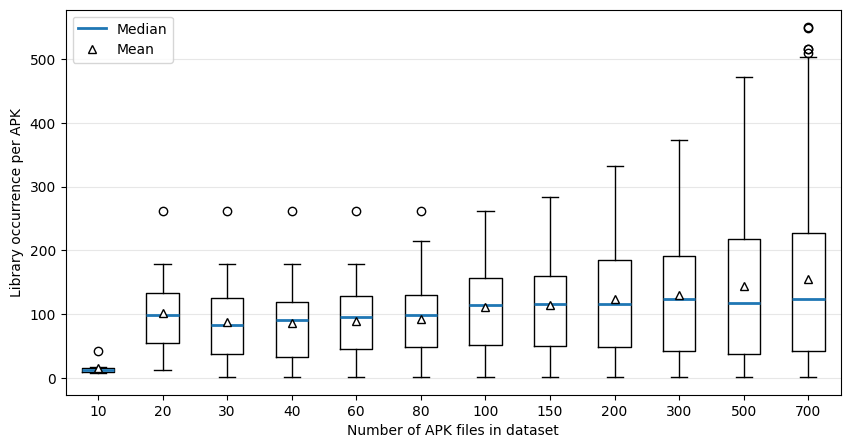

In [11]:
from matplotlib.lines import Line2D

boxplot_data = [
    rows_per_pkg_all.loc[rows_per_pkg_all['dataset_size'] == size, 'library_occurrence_rows'].values
    for size in DATASET_SUFFIX
]

plt.figure(figsize=(10, 5))
plt.boxplot(
    boxplot_data,
    tick_labels=DATASET_SUFFIX,
    showmeans=True,
    meanprops={'marker': '^', 'markerfacecolor': 'white', 'markeredgecolor': 'black'},
    medianprops={'linewidth': 2, 'color': '#1f77b4'}
)
# plt.title('Distribution of Library Occurrence per APK')
plt.xlabel('Number of APK files in dataset')
plt.ylabel('Library occurrence per APK')
plt.grid(True, axis='y', alpha=0.3)

legend_handles = [
    Line2D([0], [0], linewidth=2, label='Median', color='#1f77b4'),
    Line2D([0], [0], marker='^', linestyle='None', markerfacecolor='white', markeredgecolor='black', label='Mean')
]
plt.legend(handles=legend_handles, loc='upper left')
save_current_figure('library_occurrence_rows_per_apk_distribution_boxplot.png')
plt.show()

## 11. Trend: average, median, min, and max rows per APK

This provides a more direct view of how the per-APK library occurrence distribution changes as the dataset gets larger.

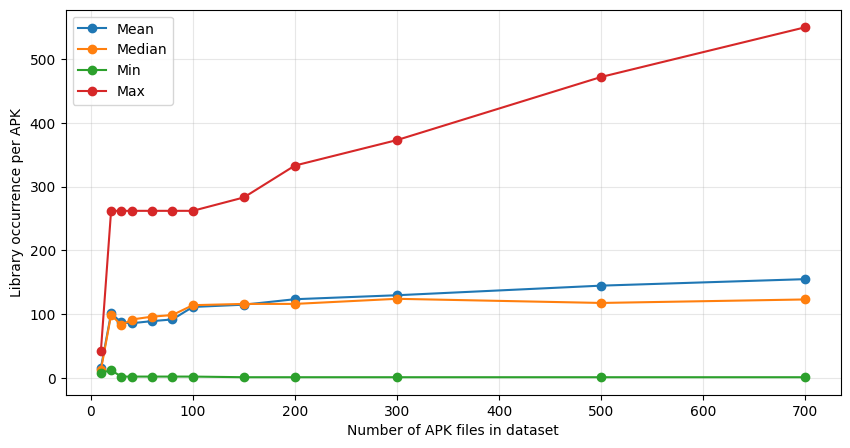

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(kpi_summary['dataset_size'], kpi_summary['rows_per_pkg_mean'], marker='o', label='Mean')
plt.plot(kpi_summary['dataset_size'], kpi_summary['rows_per_pkg_median'], marker='o', label='Median')
plt.plot(kpi_summary['dataset_size'], kpi_summary['rows_per_pkg_min'], marker='o', label='Min')
plt.plot(kpi_summary['dataset_size'], kpi_summary['rows_per_pkg_max'], marker='o', label='Max')
# plt.title('Rows per APK Summary Statistics by Dataset Size')
plt.xlabel('Number of APK files in dataset')
plt.ylabel('Library occurrence per APK')
plt.legend()
plt.grid(True, alpha=0.3)
save_current_figure('rows_per_apk_summary_statistics_by_dataset_size.png')
plt.show()

## 12. Fingerprint type ratios by dataset size

This table and chart show the ratio of each `fingerprint_type` within every dataset size.

In [37]:
fingerprint_type_pivot = (
    fingerprint_type_summary_all
    .pivot_table(
        index='dataset_size',
        columns='fingerprint_type',
        values='ratio',
        aggfunc='sum',
        fill_value=0
    )
    .sort_index()
)

fingerprint_type_pivot

fingerprint_type,3rdpartylicenses,generic_text_repo_url,gradle_group_prefix,java_package,javascript_define,js_license_header,json_license_heuristic,kotlin_package,manifest_package,maven_artifact_root,maven_group_prefix
dataset_size,,,,,,,,,,,
10,0.024390,0.000000,0.016260,0.617886,0.000000,0.341463,0.000000,0.000000,0.000000,0.000000,0.000000
20,0.001648,0.000000,0.003846,0.724176,0.000000,0.028022,0.108791,0.124176,0.008791,0.000000,0.000549
30,0.001148,0.001530,0.003443,0.750574,0.000000,0.022188,0.076894,0.134277,0.009564,0.000000,0.000383
40,0.000876,0.001751,0.003503,0.757151,0.000584,0.023059,0.058961,0.144191,0.009632,0.000000,0.000292
60,0.000562,0.002622,0.003745,0.764045,0.000375,0.033895,0.037828,0.146816,0.009925,0.000000,0.000187
80,0.000409,0.002592,0.003684,0.770091,0.000273,0.029063,0.027698,0.156229,0.009688,0.000000,0.000273
100,0.000270,0.002338,0.003237,0.644219,0.000180,0.022658,0.018612,0.300306,0.007912,0.000000,0.000270
150,0.000174,0.003543,0.003253,0.605693,0.002207,0.025966,0.013535,0.334940,0.008946,0.000000,0.001743
200,0.000122,0.002675,0.003283,0.580172,0.001743,0.018766,0.009444,0.373865,0.008309,0.000000,0.001621


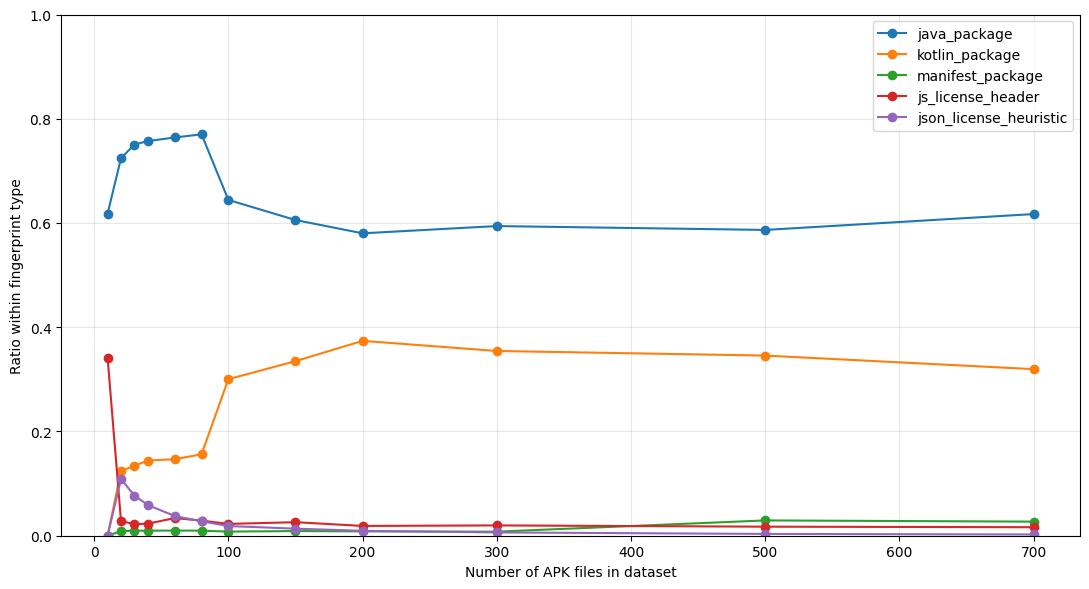

In [41]:
# Select the top fingerprint types overall to keep the chart readable
TOP_N = 5

top_fp_types = (
    fingerprint_type_summary_all
    .groupby('fingerprint_type')['count']
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

plt.figure(figsize=(11, 6))
for fp_type in top_fp_types:
    plt.plot(
        fingerprint_type_pivot.index,
        fingerprint_type_pivot[fp_type] if fp_type in fingerprint_type_pivot.columns else 0,
        marker='o',
        label=fp_type
    )

# plt.title(f'Top {TOP_N} Fingerprint Type Ratios by APK Collection Size')
plt.xlabel('Number of APK files in dataset')
plt.ylabel('Ratio within fingerprint type')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_current_figure('top_fingerprint_type_ratios_by_apk_collection_size.png')
plt.show()

## 13. Optional: fingerprint type ratio table as percentages

In [39]:
fingerprint_type_percent = (fingerprint_type_pivot * 100).round(2)
fingerprint_type_percent.to_csv(OUTPUT_DIR / 'fingerprint_type_ratio_percent_pivot.csv')
fingerprint_type_percent

fingerprint_type,3rdpartylicenses,generic_text_repo_url,gradle_group_prefix,java_package,javascript_define,js_license_header,json_license_heuristic,kotlin_package,manifest_package,maven_artifact_root,maven_group_prefix
dataset_size,,,,,,,,,,,
10,2.44,0.00,1.63,61.79,0.00,34.15,0.00,0.00,0.00,0.00,0.00
20,0.16,0.00,0.38,72.42,0.00,2.80,10.88,12.42,0.88,0.00,0.05
30,0.11,0.15,0.34,75.06,0.00,2.22,7.69,13.43,0.96,0.00,0.04
40,0.09,0.18,0.35,75.72,0.06,2.31,5.90,14.42,0.96,0.00,0.03
60,0.06,0.26,0.37,76.40,0.04,3.39,3.78,14.68,0.99,0.00,0.02
80,0.04,0.26,0.37,77.01,0.03,2.91,2.77,15.62,0.97,0.00,0.03
100,0.03,0.23,0.32,64.42,0.02,2.27,1.86,30.03,0.79,0.00,0.03
150,0.02,0.35,0.33,60.57,0.22,2.60,1.35,33.49,0.89,0.00,0.17
200,0.01,0.27,0.33,58.02,0.17,1.88,0.94,37.39,0.83,0.00,0.16


## 14. Final saved outputs

The notebook saves the following outputs in `OUTPUT_DIR`:

### Per dataset size

- `dataset_10_transformed.csv`, `dataset_20_transformed.csv`, ...
- `rows_per_pkg_10.csv`, `rows_per_pkg_20.csv`, ...
- `fingerprint_type_summary_10.csv`, `fingerprint_type_summary_20.csv`, ...

### Combined files

- `all_datasets_transformed_combined.csv`
- `kpi_summary_by_dataset_size.csv`
- `rows_per_pkg_all_dataset_sizes.csv`
- `fingerprint_type_summary_all_dataset_sizes.csv`
- `fingerprint_type_ratio_percent_pivot.csv`

In [40]:
print('Files currently saved in OUTPUT_DIR:')
for path in sorted(OUTPUT_DIR.glob('*')):
    print('-', path.name)

Files currently saved in OUTPUT_DIR:
- .DS_Store
- activity_vs_fragility.png
- all_datasets_transformed_combined.csv
- cited_ratio_by_apk_collection_size.png
- cited_vs_not_cited_counts_by_apk_collection_size.png
- dataset_100_transformed.csv
- dataset_10_transformed.csv
- dataset_150_transformed.csv
- dataset_200_transformed.csv
- dataset_20_transformed.csv
- dataset_300_transformed.csv
- dataset_30_transformed.csv
- dataset_40_transformed.csv
- dataset_500_medium_fragility_apk_usage.csv
- dataset_500_medium_fragility_row_details.csv
- dataset_500_medium_fragility_uncited_apk_usage.csv
- dataset_500_medium_fragility_uncited_row_details.csv
- dataset_500_repo_github_enriched_metrics.csv
- dataset_500_rows_with_github_repo_identifier.csv
- dataset_500_summary_kpis.csv
- dataset_500_transformed.csv
- dataset_60_transformed.csv
- dataset_700_medium_fragility_apk_usage.csv
- dataset_700_medium_fragility_row_details.csv
- dataset_700_medium_fragility_uncited_apk_usage.csv
- dataset_700_medi